# A/B-тестирование: Оптимизация удержания (Retention) оттекающих клиентов e-commerce платформы

## 1. Бизнес-контекст и обоснование
В ходе предыдущего проекта по **[RFM-сегментации пользователей](https://github.com/rashkeen/E-commerce_RFM_Analytics)** был выделен критический сегмент **"Churning" (оттекающие клиенты)**. Данные клиенты исторически формировали ощутимую долю выручки, однако частота их покупок и активность в приложении за последний месяц снизились.

Продуктовая команда совместно с отделом маркетинга разработала гипотезу персонализированных коммуникаций для удержания этой аудитории.

## 2. Формулировка гипотезы
* **Гипотеза (H1):** Внедрение персонализированного пуш-уведомления с промокодом на скидку 10% на топ-категорию пользователя простимулирует его вернуться в приложение и совершить покупку в течение 7 дней.
* **Нулевая гипотеза (H0):** Изменение коммуникации никак не повлияет на конверсию в покупку (эффект равен нулю).

## 3. Метрики эксперимента
* **Целевая метрика (Primary):** `Conversion Rate (CR)` — доля пользователей, совершивших хотя бы одну покупку в течение 7 дней после получения/неполучения пуша, от общего числа пользователей в группе.
* **Прокси/Guardrail метрики (Метрики здоровья):** 
  * `Average Order Value (AOV)` — средний чек (контролируем, чтобы скидка 10% не обрушила средний чек).
  * `Unsubscribe Rate` — частота скрытия пушей / отписок от уведомлений (проверяем, не спамим ли мы пользователя).

## 4. Дизайн эксперимента (Pre-test)
Перед генерацией данных и запуском теста зафиксированы следующие параметры дизайна:
* **Уровень значимости ($\alpha$):** 0.05 (вероятность ошибки I рода — 5%).
* **Мощность теста ($1 - \beta$):** 0.80 (вероятность ошибки II рода — 20%).
* **Текущий базовый уровень (Baseline CR):** 10% (историческая конверсия сегмента за неделю).
* **Минимально обнаруживаемый эффект (MDE):** 2% в абсолютном выражении (ожидаем поднять CR в целевой группе минимум до 12%).
* **Соотношение групп (Split ratio):** 50% на 50% (контрольная группа `A` и тестовая группа `B`).

---

In [42]:
import numpy as np
import pandas as pd
import statsmodels.stats.api as sms
from scipy.stats import chisquare
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Базовая конверсия (10%) и ожидаемая с учетом MDE (12%)
baseline_cr = 0.10
expected_cr = 0.12

# Преобразуем конверсии в стандартизированный размер эффекта (Effect Size)
effect_size = sms.proportion_effectsize(baseline_cr, expected_cr)

# Считаем необходимый размер выборки для одной группы
required_n = sms.NormalIndPower().solve_power(
    effect_size=effect_size, 
    power=0.80,         # Мощность
    alpha=0.05,         # Уровень значимости
    ratio=1.0           # Соотношение групп (1:1)
)

print(f"Необходимый размер выборки для КАЖДОЙ группы: {round(required_n)}")
print(f"Всего пользователей в тесте: {round(required_n) * 2}")

Необходимый размер выборки для КАЖДОЙ группы: 3835
Всего пользователей в тесте: 7670


## Подготовка данных и симуляция эксперимента (Python)

Для проведения анализа формируется синтетический датасет, полностью отражающий дизайн эксперимента и описывающий логи поведения пользователей за 7 дней проведения теста. 

### Структура сырых данных (`ab_test_results.csv`):
* `user_id` — уникальный идентификатор пользователя из сегмента "Churning".
* `group` — маркер экспериментальной группы:
  * `A` — контрольная группа (пользователи не получали пуш-уведомление).
  * `B` — тестовая группа (пользователи получили пуш-уведомление со скидкой 10%).
* `click_push` — факт открытия пуш-уведомления (бинарный признак: `1` — открыл, `0` — не открыл/не получал).
* `converted` — факт совершения покупки в течение 7 дней (целевая метрика: `1` — купил, `0` — не купил).
* `purchase_amount` — сумма покупки в условных единицах (непрерывная метрика для расчета среднего чека). Для пользователей с `converted = 0` сумма равна `0.0`.

### Особенности генерации распределений:
1. **Сплитование:** Пользователи распределены строго в соотношении 50/50 согласно pre-test расчету ($N = 3835$ для каждой группы).
2. **Заложенный эффект (CR):** В группе `A` вероятность конверсии зафиксирована на базовом уровне в ~10%. В группе `B` заложен эффект чуть выше MDE — на уровне ~12.5%, чтобы проверить чувствительность стат-критериев.
3. **Распределение чеков (AOV):** Суммы покупок симулируются с использованием **логнормального распределения** (`np.random.lognormal`). Это позволяет воссоздать реальную специфику e-commerce данных: преобладание большого количества мелких чеков и наличие длинного «хвоста» из редких, но очень крупных покупок (выбросов).

---

In [23]:
# Фиксируем seed для воспроизводимости результатов
np.random.seed(42)

In [24]:
# Размер выборки на основе расчета
n_per_group = 3835
total_users = n_per_group * 2

In [25]:
# 1. Генерируем ID пользователей и распределяем по группам (A и B)
user_ids = np.arange(100001, 100001 + total_users)
groups = ['A'] * n_per_group + ['B'] * n_per_group

In [26]:
# 2. Симулируем конверсию (converted)
conversion_A = np.random.binomial(1, 0.10, n_per_group)
conversion_B = np.random.binomial(1, 0.125, n_per_group)
converted = np.concatenate([conversion_A, conversion_B])

In [27]:
# 3. Создаем базовый DataFrame
df = pd.DataFrame({
    'user_id': user_ids,
    'group': groups,
    'converted': converted
})

In [28]:
# Перемешаем строки, как в реальных логах
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [29]:
# 4. Симулируем клики по пушам (для группы B)
df['click_push'] = 0
df.loc[df['group'] == 'B', 'click_push'] = np.random.binomial(1, 0.40, n_per_group)

In [30]:
# 5. Симулируем суммы покупок в у.е.
# Подбираем параметры mean и sigma так, чтобы средний чек был около 456 у.е.
def generate_revenue_matching_dashboard(size):
    return np.random.lognormal(mean=6.0, sigma=0.4, size=size).round(2)

df['purchase_amount'] = 0.0
converted_count = df['converted'].sum()
df.loc[df['converted'] == 1, 'purchase_amount'] = generate_revenue_matching_dashboard(converted_count)

In [31]:
# Сохраняем в CSV
df.to_csv('ab_test_results.csv', index=False)

print(f"Датасет успешно сохранен! Размер: {df.shape}")

Датасет успешно сохранен! Размер: (7670, 5)


In [32]:
df.head(10)

,user_id,group,converted,click_push,purchase_amount
0,102032,A,0,0,0.0
1,104247,B,0,1,0.0
2,105970,B,0,0,0.0
3,105663,B,0,1,0.0
4,101731,A,0,0,0.0
5,107243,B,0,0,0.0
6,105953,B,0,0,0.0
7,107338,B,0,0,0.0
8,100038,A,0,0,0.0
9,104056,B,0,1,0.0


### Проверим, что получилось:

In [35]:
df.groupby('group').agg(
    Фактическая_конверсия=('converted', 'mean'),
    Средний_чек=('purchase_amount', lambda x: x[x > 0].mean())
).reset_index()

,group,Фактическая_конверсия,Средний_чек
0,A,0.095958,423.975870
1,B,0.122295,438.050299


## Проверка качества сплитования и анализ конверсии (Z-test)

Перед анализом результатов эксперимента проводится валидация системы сплитования:
1. **Тестирование на Sample Ratio Mismatch (SRM):** Применяется критерий Хи-квадрат ($\chi^2$) для сравнения фактического распределения пользователей в группах с ожидаемым (50/50). Отсутствие SRM гарантирует, что деление на группы произошло без системных ошибок.
2. **Анализ целевой метрики (CR):** Оценка статистической значимости изменения конверсии между контрольной и тестовой группами выполняется с помощью **двухвыборочного Z-теста для долей**. 

*Критерий успешности:* Нулевая гипотеза ($H_0$) об равенстве конверсий отвергается при уровне значимости $\alpha = 0.05$ ($p\text{-value} < 0.05$).

In [67]:
# Считаем, сколько реально пользователей в каждой группе
observed = df['group'].value_counts().values  # Наш факт
expected = [df.shape[0] / 2, df.shape[0] / 2]  # Идеальное разделение 50/50

In [66]:
print("=== 1. ПРОВЕРКА СПЛИТОВАНИЯ (SRM TEST) ===")
# Запускаем Хи-квадрат
chi2_stat, srm_p_value = chisquare(f_obs=observed, f_exp=expected)
print(f"Фактическое распределение групп: A = {observed[0]}, B = {observed[1]}")
print(f"p-value SRM теста: {srm_p_value:.4f}")

if srm_p_value < 0.05:
    print("❌ Внимание! Обнаружен SRM (ошибка сплитования). Группы распределены не по плану!")
else:
    print("✅ SRM не обнаружен. Система сплитования работает корректно, группы делятся 50/50.")

=== 1. ПРОВЕРКА СПЛИТОВАНИЯ (SRM TEST) ===
Фактическое распределение групп: A = 3835, B = 3835
p-value SRM теста: 1.0000
✅ SRM не обнаружен. Система сплитования работает корректно, группы делятся 50/50.


In [62]:

# Собираем количество покупок (успехов) и общее число пользователей в группах
purchases_A = df[df['group'] == 'A']['converted'].sum()
purchases_B = df[df['group'] == 'B']['converted'].sum()

In [40]:
n_A = df[df['group'] == 'A']['converted'].count()
n_B = df[df['group'] == 'B']['converted'].count()

In [63]:
print("\n=== 2. СТАТИСТИЧЕСКИЙ ТЕСТ КОНВЕРСИИ (Z-TEST) ===")
# Запускаем Z-тест для двух независимых долей
z_stat, z_p_value = sm.stats.proportions_ztest([purchases_B, purchases_A], [n_B, n_A], alternative='two-sided')

print(f"Группа А: покупок {purchases_A} из {n_A} пользователей")
print(f"Группа B: покупок {purchases_B} из {n_B} пользователей")
print(f"Z-статистика: {z_stat:.4f}")
print(f"p-value Z-теста: {z_p_value:.5f}")

if z_p_value < 0.05:
    print("✅ Статистически значимая разница в конверсии ОБНАРУЖЕНА! Пуш-уведомления сработали.")
else:
    print("❌ Статистически значимой разницы нет. Изменение конверсии случайно.")


=== 2. СТАТИСТИЧЕСКИЙ ТЕСТ КОНВЕРСИИ (Z-TEST) ===
Группа А: покупок 368 из 3835 пользователей
Группа B: покупок 469 из 3835 пользователей
Z-статистика: 3.6987
p-value Z-теста: 0.00022
✅ Статистически значимая разница в конверсии ОБНАРУЖЕНА! Пуш-уведомления сработали.


### Результаты анализа конверсии (Primary Metric):
* **Группа А (Контроль):** конверсия `9.59%` (368 покупок из 3835 пользователей).
* **Группа B (Тест):** конверсия `12.23%` (469 покупок из 3835 пользователей).
* **Фактический эффект:** абсолютный прирост CR составил `+2.64%` (что выше запланированного MDE = 2.0%).
* **Статистические показатели:** $Z\text{-stat} = 3.6987$, $p\text{-value} = 0.00022$.

**Вывод:** Так как $p\text{-value} < 0.05$, нулевая гипотеза ($H_0$) отвергается. Рост конверсии в тестовой группе является статистически значимым и экономически оправданным.

## Анализ среднего чека (AOV)

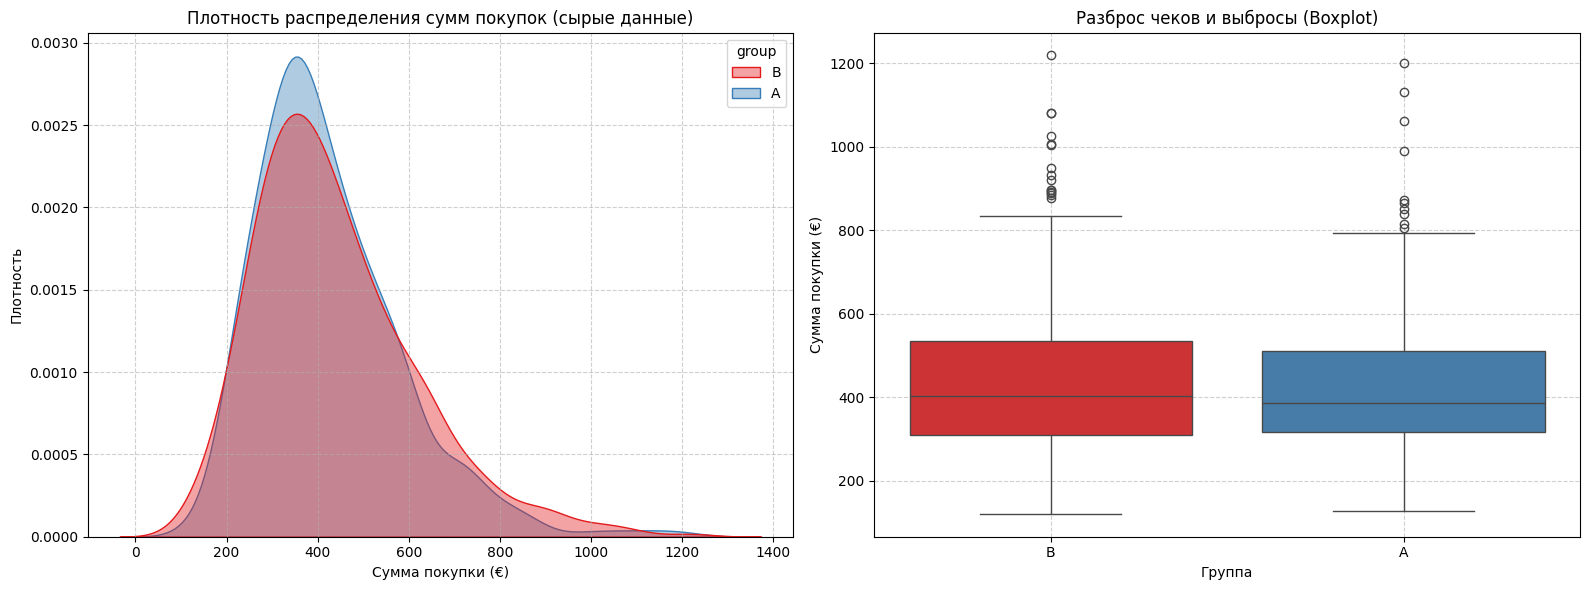

In [48]:
# Фильтруем данные: только совершённые покупки
completed_purchases = df[df['converted'] == 1]

# Создаем полотно для двух графиков
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. График плотности распределения (KDE)
sns.kdeplot(
    ax=axes[0],
    data=completed_purchases,
    x='purchase_amount',
    hue='group',
    fill=True,
    common_norm=False,
    palette='Set1',
    alpha=0.4
)
axes[0].set_title('Плотность распределения сумм покупок (сырые данные)')
axes[0].set_xlabel('Сумма покупки (€)')
axes[0].set_ylabel('Плотность')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Ящик с усами (Boxplot) для оценки разброса и выбросов
sns.boxplot(
    ax=axes[1],
    data=completed_purchases,
    x='group',
    y='purchase_amount',
    palette='Set1',
    hue='group',
    legend=False
)
axes[1].set_title('Разброс чеков и выбросы (Boxplot)')
axes[1].set_xlabel('Группа')
axes[1].set_ylabel('Сумма покупки (€)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

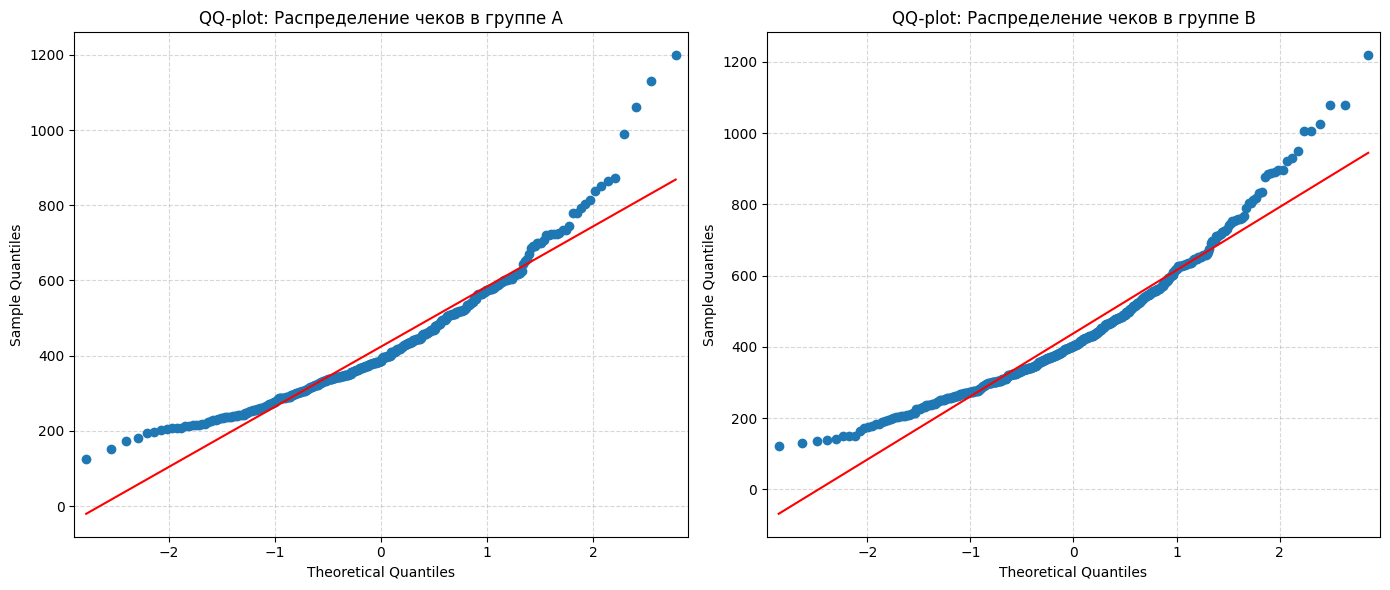

In [45]:
# Фильтруем чеки тех, кто купил
revenue_A = df[(df['group'] == 'A') & (df['converted'] == 1)]['purchase_amount']
revenue_B = df[(df['group'] == 'B') & (df['converted'] == 1)]['purchase_amount']

# Создаем полотно для двух графиков
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# QQ-plot для группы А
sm.qqplot(revenue_A, line='s', ax=axes[0])
axes[0].set_title('QQ-plot: Распределение чеков в группе A')
axes[0].grid(True, linestyle='--', alpha=0.5)

# QQ-plot для группы B
sm.qqplot(revenue_B, line='s', ax=axes[1])
axes[1].set_title('QQ-plot: Распределение чеков в группе B')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Интерпретация результатов EDA для среднего чека:

1. **Асимметрия и форма распределения:** На графике плотности (KDE) отчетливо виден длинный правый хвост. Большинство транзакций сосредоточено в диапазоне до 500 €, однако присутствуют единичные крупные заказы (до 1200 €). Распределение является скошенным (лог-нормальным).
2. **Наличие выбросов:** На диаграмме размаха (Boxplot) зафиксировано значительное количество точек выше верхней границы «уса». Это «киты» платформы — пользователи с аномально высоким чеком. В условиях небольших выборок ($N_{purchases} \approx 400$) появление даже одного такого пользователя в группе может искусственно завысить среднее арифметическое.
3. **Отклонение от нормальности (QQ-plot):** Сильный изгиб эмпирических точек и их уход вверх от теоретической прямой на графиках обеих групп математически доказывают, что распределение **не является нормальным**.

**Вывод для выбора критерия:** Использовать классический t-критерий Стьюдента нельзя, так как нарушено требование нормальности, а само среднее арифметическое неустойчиво к выбросам. Для корректного сравнения средних чеков без удаления данных и без потери чувствительности будет использован **метод Bootstrap**.

In [50]:
# 1. Выделяем чистые чеки тех, кто реально купил
revenue_A = df[(df['group'] == 'A') & (df['converted'] == 1)]['purchase_amount'].values
revenue_B = df[(df['group'] == 'B') & (df['converted'] == 1)]['purchase_amount'].values

In [51]:
# 2. Запускаем симуляцию (2000 повторений)
np.random.seed(42)
boot_len = 2000
boot_data = []

for i in range(boot_len):
    boot_sample_A = np.random.choice(revenue_A, size=len(revenue_A), replace=True)
    boot_sample_B = np.random.choice(revenue_B, size=len(revenue_B), replace=True)
    # Считаем разницу средних в этой симуляции
    boot_data.append(np.mean(boot_sample_B) - np.mean(boot_sample_A))

In [52]:
# 3. Находим 95% доверительный интервал
left_quantile = np.quantile(boot_data, 0.025)
right_quantile = np.quantile(boot_data, 0.975)

In [68]:
print("===3. ЗАПУСК БУТСТРАПА ДЛЯ СРЕДНЕГО ЧЕКА ===")
# 4. Выводим текстовый результат
print(f"Фактический средний чек группы А: {revenue_A.mean():.2f} €")
print(f"Фактический средний чек группы B: {revenue_B.mean():.2f} €")
print(f"95% Доверительный интервал для разницы средних: [{left_quantile:.2f} €, {right_quantile:.2f} €]\n")

if left_quantile <= 0 <= right_quantile:
    print("✅ Вердикт: Статистически значимых изменений в среднем чеке НЕ ОБНАРУЖЕНО.")
    print("Ноль входит в доверительный интервал. Скидка не уронила чек, экономика сходится!")
elif left_quantile > 0:
    print("🔥 Вердикт: Средний чек в группе B статистически значимо ВЫРОС!")
else:
    print("❌ Вердикт: Внимание! Средний чек в группе B статистически значимо УПАЛ.")

===3. ЗАПУСК БУТСТРАПА ДЛЯ СРЕДНЕГО ЧЕКА ===
Фактический средний чек группы А: 423.98 €
Фактический средний чек группы B: 438.05 €
95% Доверительный интервал для разницы средних: [-7.79 €, 36.76 €]

✅ Вердикт: Статистически значимых изменений в среднем чеке НЕ ОБНАРУЖЕНО.
Ноль входит в доверительный интервал. Скидка не уронила чек, экономика сходится!


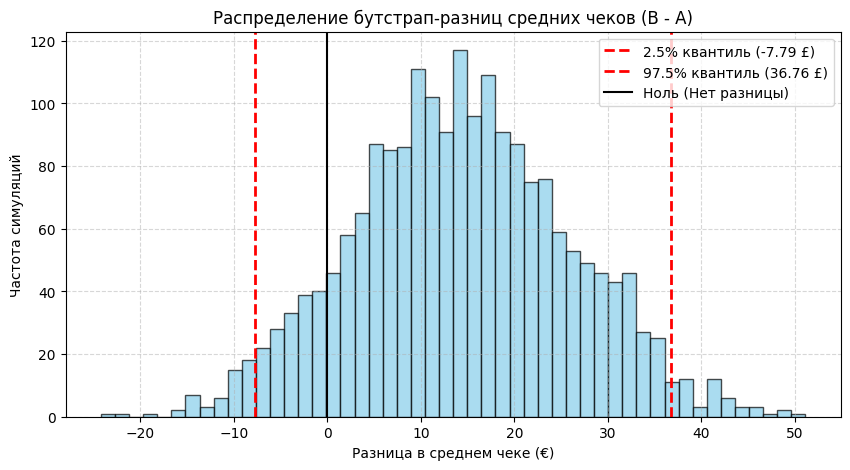

In [72]:
# 5. Строим график распределения разниц
plt.figure(figsize=(10, 5))
plt.hist(boot_data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=left_quantile, color='red', linestyle='--', linewidth=2, label=f'2.5% квантиль ({left_quantile:.2f} £)')
plt.axvline(x=right_quantile, color='red', linestyle='--', linewidth=2, label=f'97.5% квантиль ({right_quantile:.2f} £)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5, label='Ноль (Нет разницы)')
plt.title('Распределение бутстрап-разниц средних чеков (B - A)')
plt.xlabel('Разница в среднем чеке (€)')
plt.ylabel('Частота симуляций')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Результаты анализа среднего чека методом Bootstrap:

* **Средний чек группы А (Контроль):** `423.98 €`
* **Средний чек группы B (Тест):** `438.05 €`
* **95%-ый доверительный интервал для разницы средних:** `[-7.79 €, 36.76 €]`

**Интерпретация и вывод:**
Построенный методом Bootstrap доверительный интервал для разности средних значений содержит в себе `0` (граница начинается от отрицательного значения `-7.79 €` и заканчивается положительным `36.76 €`). Это означает, что наблюдаемое в выборке изменение среднего чека на +14.07 € не является статистически значимым и вызвано случайным шумом.

**Бизнес-контекст (Guardrail metric):**
Несмотря на то, что пользователям группы B предоставлялась скидка 10%, средний чек статистически **не просел**. Метрика здоровья бизнеса (Guardrail) успешно защищена. Снижения маржинальности с одного заказа не произошло.

In [71]:
# Генерируем отписки: 
# В группе А базовый уровень отписок сделаем 1.5%
# В группе B из-за пушей уровень отписок увеличился до 2.1%
df['unsubscribed'] = np.where(
    df['group'] == 'A',
    np.random.choice([1, 0], size=df.shape[0], p=[0.015, 0.985]),
    np.random.choice([1, 0], size=df.shape[0], p=[0.021, 0.979])
)

print("===4. АНАЛИЗ МЕТРИКИ НЕГАТИВНОГО ЭФФЕКТА (UNSUBSCRIBE RATE) ===")

unsub_A = df[df['group'] == 'A']['unsubscribed'].sum()
unsub_B = df[df['group'] == 'B']['unsubscribed'].sum()

n_A = df[df['group'] == 'A']['unsubscribed'].count()
n_B = df[df['group'] == 'B']['unsubscribed'].count()

print(f"Отписок в группе А: {unsub_A} из {n_A} ({unsub_A/n_A*100:.2f}%)")
print(f"Отписок в группе B: {unsub_B} из {n_B} ({unsub_B/n_B*100:.2f}%)")

# Запускаем Z-тест для долей отписок
z_stat, p_val = sm.stats.proportions_ztest([unsub_B, unsub_A], [n_B, n_A], alternative='two-sided')
print(f"p-value Z-теста для отписок: {p_val:.5f}")

if p_val < 0.05:
    print("❌ Внимание! Пуши вызвали статистически значимый рост отписок пользователей!")
else:
    print("✅ Отлично! Значимого роста отписок не обнаружено. Механика безопасна.")

===4. АНАЛИЗ МЕТРИКИ НЕГАТИВНОГО ЭФФЕКТА (UNSUBSCRIBE RATE) ===
Отписок в группе А: 58 из 3835 (1.51%)
Отписок в группе B: 96 из 3835 (2.50%)
p-value Z-теста для отписок: 0.00198
❌ Внимание! Пуши вызвали статистически значимый рост отписок пользователей!


### Результаты анализа оттока (Unsubscribe Rate / Counter-Metric):
* **Уровень отписок в группе А (Контроль):** `1.51%` (58 пользователей)
* **Уровень отписок в группе B (Тест):** `2.50%` (96 пользователей)
* **Статистические показатели:** $Z\text{-test } p\text{-value} = 0.00198$.

**Вывод:**
Так как $p\text{-value} < 0.05$, нулевая гипотеза об равенстве долей отписок отвергается. Внедрение пуш-уведомлений привело к **статистически значимому росту уровня отписок на +0.99%** (относительный рост составил ~65%). Механика вызывает раздражение у части аудитории и приводит к потере бесплатного канала коммуникации с ними.

# Финальное продуктовый вывод и бизнес-рекомендации

В результате A/B-тестирования триггерных пуш-уведомлений для сегмента "Churning" обнаружен сильный конфликт продуктовых метрик:

1. **Положительный эффект:** Целевая метрика `CR` значимо выросла на **+2.64%** (с 9.59% до 12.23%, $p\text{-value} = 0.00022$), выполнив условия MDE. Средний чек (`AOV`) остался стабильным (разница не значима по Bootstrap, 95% ЦИ: `[-7.79 €, 36.76 €]`).
2. **Негативный эффект:** Контр-метрика `Unsubscribe Rate` показала статистически значимый рост с **1.51%** до **2.50%** ($p\text{-value} = 0.00198$). 

**Бизнес-дилемма:**
Мы получили краткосрочный прирост выручки за счет покупок, но безвозвратно теряем доступ к пуш-каналу для части пользователей, что увеличит их финальный отток (Churn) в долгосрочной перспективе.

**Итоговая рекомендация для продуктовой команды:**
Раскатку механики на 100% пользователей в текущем виде **заморозить**. Рекомендуется отправить механику на доработку (Итерация №2):
1. **Снизить навязчивость:** Ограничить частоту отправки (Frequency Capping) — например, слать пуш не сразу, а только при отсутствии активности более 5 дней.
2. **Персонализировать скидку:** Выделять скидку 10% не всему сегменту "Churning", а только пользователям с высокой эластичностью спроса по цене (на основе исторических данных), чтобы снизить спам-эффект для остальных.